# Чекпойнт 6: Нейронные сети для предсказания матчей НБА

В этом ноутбуке применяем нейронные сети (PyTorch) для бинарной классификации: победит ли домашняя команда.

**Архитектуры, которые будем тестировать:**
1. **Simple MLP** — базовый многослойный перцептрон (2 скрытых слоя)
2. **Regularized MLP** — MLP с BatchNorm + Dropout
3. **Residual MLP** — MLP с остаточными (skip) соединениями
4. **Attention MLP** — MLP с механизмом мягкого внимания по признакам
5. **Ensemble of NNs** — усредненный ансамбль нескольких обученных сетей

**Стратегия валидации** — хронологическое разделение (без утечки данных из будущего).

**Финал** — сравнение DL-подходов с лучшими ML-моделями из предыдущего чекпойнта.

## 1. Импорты и конфигурация

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, classification_report

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch версия: {torch.__version__}')
print(f'Устройство: {DEVICE}')


PyTorch версия: 2.10.0+cu128
Устройство: cuda


## 2. Загрузка данных и разбивка

In [7]:
df = pd.read_csv('features_engineered.csv')
print(f'Загружено {len(df)} строк и {len(df.columns)} столбцов')

recommended_features = [
    'elo_diff', 'home_elo_before', 'away_elo_before',
    'win_rate_diff_L20', 'win_rate_diff_L10', 'win_rate_diff_L5',
    'home_win_rate_L20', 'home_win_rate_L10', 'home_win_rate_L5',
    'away_win_rate_L20', 'away_win_rate_L10', 'away_win_rate_L5',
    'fg_pct_diff_L20', 'fg_pct_diff_L10', 'fg_pct_diff_L5',
    'fg3_pct_diff_L20', 'fg3_pct_diff_L10', 'fg3_pct_diff_L5',
    'h2h_home_win_rate', 'h2h_total_games',
    'season_progress',
]

available_features = [f for f in recommended_features if f in df.columns]
X = df[available_features].copy()
y = df['home_win'].copy()

mask = ~(X.isna().any(axis=1) | y.isna())
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

print(f'Используем {len(available_features)} признаков: {available_features}')
print(f'Строк после удаления пропусков: {len(X)}')
print(f'Доля побед домашних команд: {y.mean():.3f}')


Загружено 72629 строк и 96 столбцов
Используем 21 признаков: ['elo_diff', 'home_elo_before', 'away_elo_before', 'win_rate_diff_L20', 'win_rate_diff_L10', 'win_rate_diff_L5', 'home_win_rate_L20', 'home_win_rate_L10', 'home_win_rate_L5', 'away_win_rate_L20', 'away_win_rate_L10', 'away_win_rate_L5', 'fg_pct_diff_L20', 'fg_pct_diff_L10', 'fg_pct_diff_L5', 'fg3_pct_diff_L20', 'fg3_pct_diff_L10', 'fg3_pct_diff_L5', 'h2h_home_win_rate', 'h2h_total_games', 'season_progress']
Строк после удаления пропусков: 50843
Доля побед домашних команд: 0.588


In [8]:
split_idx = int(len(X) * 0.8)
X_train_full = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train_full = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

val_size = int(len(X_train_full) * 0.15)
X_train = X_train_full.iloc[:-val_size].copy()
y_train = y_train_full.iloc[:-val_size].copy()
X_val = X_train_full.iloc[-val_size:].copy()
y_val = y_train_full.iloc[-val_size:].copy()

print(f'Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}')


Train: 34573 | Validation: 6101 | Test: 10169


## 3. Нормализация признаков

Для нейронных сетей нормализация признаков критически важна — без неё градиентный спуск работает неэффективно из-за разных масштабов признаков. `StandardScaler` обучаем **только на train**, чтобы не допустить утечки данных.

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_train_full_scaled = scaler.transform(X_train_full)

print('Нормализация выполнена.')
print(f'Mean (первые 3 признака): {X_train_scaled.mean(axis=0)[:3].round(4)}')
print(f'Std  (первые 3 признака): {X_train_scaled.std(axis=0)[:3].round(4)}')


Нормализация выполнена.
Mean (первые 3 признака): [-0.  0. -0.]
Std  (первые 3 признака): [1. 1. 1.]


## 4. PyTorch Dataset и DataLoader

In [10]:
class NBADataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y,
                              dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 512

train_dataset = NBADataset(X_train_scaled, y_train)
val_dataset = NBADataset(X_val_scaled, y_val)
test_dataset = NBADataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

INPUT_DIM = X_train_scaled.shape[1]
print(f'Входная размерность: {INPUT_DIM}')
print(f'Батчей в train_loader: {len(train_loader)}')


Входная размерность: 21
Батчей в train_loader: 68


## 5. Вспомогательные функции: обучение и оценка

In [11]:
def find_best_threshold(y_true, y_proba):
    best_thr, best_f1 = 0.5, -1.0
    for thr in np.arange(0.30, 0.71, 0.01):
        f1 = f1_score(y_true, (y_proba >= thr).astype(int))
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr, best_f1

def predict_proba(model, loader):
    model.eval()
    probs = []
    with torch.no_grad():
        for X_batch, _ in loader:
            X_batch = X_batch.to(DEVICE)
            out = model(X_batch).squeeze()
            probs.append(torch.sigmoid(out).cpu().numpy())
    return np.concatenate(probs)

def train_model(model, train_loader, val_loader,
                n_epochs=100, lr=1e-3, weight_decay=1e-4,
                patience=10, verbose=True):
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, n_epochs + 1):
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch).squeeze()
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(X_batch)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_preds_all, val_labels_all = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                logits = model(X_batch).squeeze()
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * len(X_batch)
                val_preds_all.append(torch.sigmoid(logits).cpu().numpy())
                val_labels_all.append(y_batch.cpu().numpy())
        val_loss /= len(val_loader.dataset)

        val_proba = np.concatenate(val_preds_all)
        val_labels = np.concatenate(val_labels_all)
        val_f1 = f1_score(val_labels, (val_proba >= 0.5).astype(int))

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)

        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch % 10 == 0 or epoch == 1):
            print(f'Epoch {epoch:3d} | train_loss={train_loss:.4f} '
                  f'val_loss={val_loss:.4f} val_f1={val_f1:.4f}')

        if epochs_no_improve >= patience:
            if verbose:
                print(f'Early stopping на эпохе {epoch}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'], label='Train loss')
    axes[0].plot(history['val_loss'], label='Val loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(history['val_f1'], label='Val F1', color='green')
    axes[1].set_title(f'{title} — Val F1')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

def evaluate_model(model, val_loader, test_loader, y_val_np, y_test_np, model_name):
    val_proba = predict_proba(model, val_loader)
    best_thr, val_f1 = find_best_threshold(y_val_np, val_proba)

    test_proba = predict_proba(model, test_loader)
    test_pred = (test_proba >= best_thr).astype(int)

    return {
        'model': model_name,
        'val_best_thr': round(best_thr, 2),
        'val_f1': round(val_f1, 4),
        'test_f1': round(f1_score(y_test_np, test_pred), 4),
        'test_accuracy': round(accuracy_score(y_test_np, test_pred), 4),
        'test_roc_auc': round(roc_auc_score(y_test_np, test_proba), 4),
    }

y_val_np = y_val.values
y_test_np = y_test.values

all_results = []
print('Утилиты готовы.')


Утилиты готовы.


## 6. Архитектура 1: Simple MLP

Базовая сеть из 2 скрытых слоёв с функцией активации ReLU. Никакой регуляризации — смотрим, насколько простая сеть справляется с задачей.

In [12]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

model_simple = SimpleMLP(INPUT_DIM)
print(model_simple)
n_params = sum(p.numel() for p in model_simple.parameters())
print(f'\nПараметров: {n_params:,}')


SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Параметров: 3,521


Epoch   1 | train_loss=0.6125 val_loss=0.5921 val_f1=0.7303
Epoch  10 | train_loss=0.5421 val_loss=0.6015 val_f1=0.7384
Early stopping на эпохе 17


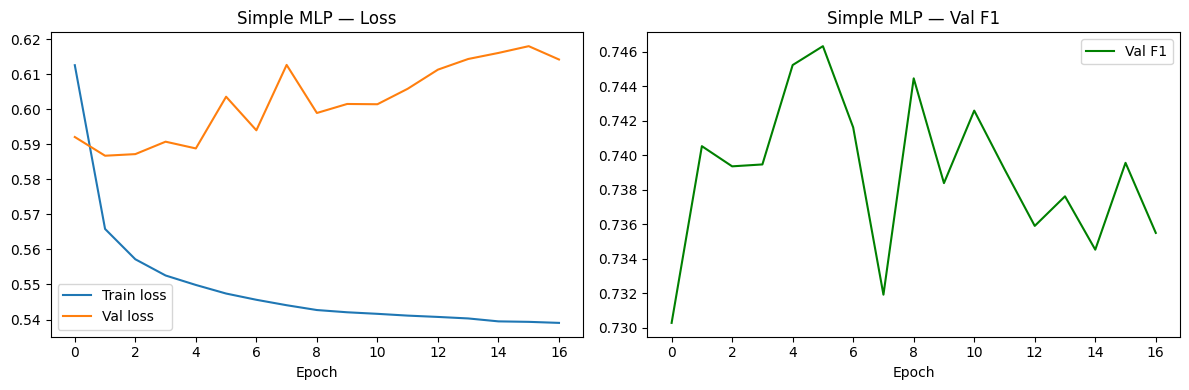

In [13]:
model_simple, history_simple = train_model(
    model_simple, train_loader, val_loader,
    n_epochs=150, lr=1e-3, weight_decay=0.0,
    patience=15, verbose=True
)
plot_history(history_simple, 'Simple MLP')


In [14]:
result_simple = evaluate_model(
    model_simple, val_loader, test_loader,
    y_val_np, y_test_np, 'Simple MLP'
)
all_results.append(result_simple)
print('Simple MLP результаты:')
pd.DataFrame([result_simple])


Simple MLP результаты:


        model  val_best_thr  val_f1  test_f1  test_accuracy  test_roc_auc
0  Simple MLP           0.4  0.7615   0.7346         0.6448        0.7137

## 7. Архитектура 2: Regularized MLP (BatchNorm + Dropout)

Добавляем **Batch Normalization** и **Dropout** для борьбы с переобучением. Batch Normalization стабилизирует обучение и позволяет использовать более высокий learning rate. Dropout случайно отключает нейроны во время обучения, заставляя сеть учить более robust признаки.

In [15]:
class RegularizedMLP(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

model_reg = RegularizedMLP(INPUT_DIM, dropout_rate=0.3)
print(model_reg)
n_params = sum(p.numel() for p in model_reg.parameters())
print(f'\nПараметров: {n_params:,}')


RegularizedMLP(
  (net): Sequential(
    (0): Linear(in_features=21, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=32, out_features=1, bias=True)
  )
)

Параметров: 13,633


Epoch   1 | train_loss=0.5941 val_loss=0.5868 val_f1=0.7366
Epoch  10 | train_loss=0.5488 val_loss=0.6166 val_f1=0.7277
Epoch  20 | train_loss=0.5451 val_loss=0.6104 val_f1=0.7362
Early stopping на эпохе 22


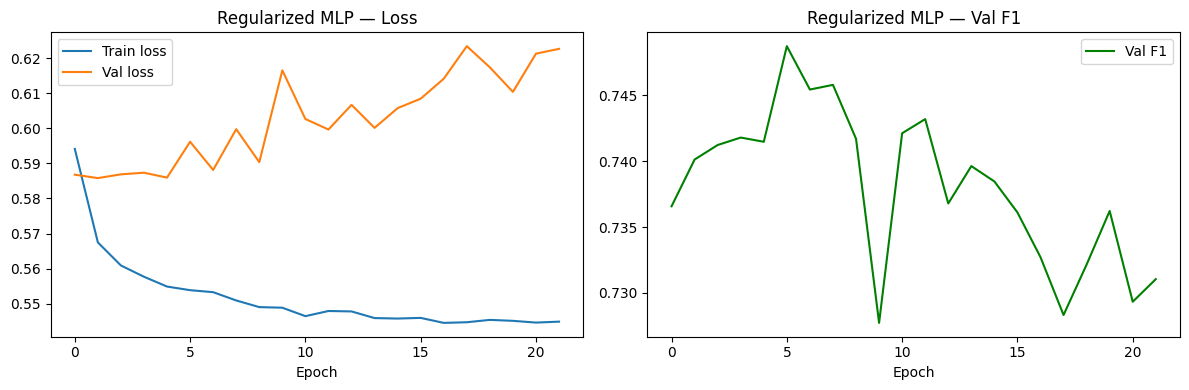

In [16]:
model_reg, history_reg = train_model(
    model_reg, train_loader, val_loader,
    n_epochs=200, lr=1e-3, weight_decay=1e-4,
    patience=20, verbose=True
)
plot_history(history_reg, 'Regularized MLP')


In [17]:
result_reg = evaluate_model(
    model_reg, val_loader, test_loader,
    y_val_np, y_test_np, 'Regularized MLP'
)
all_results.append(result_reg)
print('Regularized MLP результаты:')
pd.DataFrame([result_reg])


Regularized MLP результаты:


             model  val_best_thr  val_f1  test_f1  test_accuracy  test_roc_auc
0  Regularized MLP          0.42  0.7607   0.7361         0.6489        0.7174

## 8. Архитектура 3: Residual MLP (Skip Connections)

Добавляем **остаточные (skip) соединения** в стиле ResNet. Идея: вместо того чтобы каждый блок учился вычислять выход с нуля, он учится вычислять лишь **поправку** (residual) к входу: $H(x) = F(x) + x$.

Это решает проблему **затухающих градиентов** в глубоких сетях и позволяет строить более глубокие архитектуры.

In [18]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout_rate=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + x)

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, n_blocks=3, dropout_rate=0.2):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )
        self.blocks = nn.Sequential(
            *[ResidualBlock(hidden_dim, dropout_rate) for _ in range(n_blocks)]
        )
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.blocks(x)
        return self.head(x)

model_res = ResidualMLP(INPUT_DIM, hidden_dim=64, n_blocks=3, dropout_rate=0.2)
print(model_res)
n_params = sum(p.numel() for p in model_res.parameters())
print(f'\nПараметров: {n_params:,}')


ResidualMLP(
  (input_proj): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Linear(in_features=64, out_features=64, bias=True)
        (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Linear(in_features=64, out_features=64, bias=True)
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout(p=0.2, inplace=False)
        (4): Linear(in_features=

Epoch   1 | train_loss=0.5913 val_loss=0.5880 val_f1=0.7420
Epoch  10 | train_loss=0.5359 val_loss=0.7082 val_f1=0.7248
Epoch  20 | train_loss=0.5292 val_loss=0.7612 val_f1=0.7216
Early stopping на эпохе 21


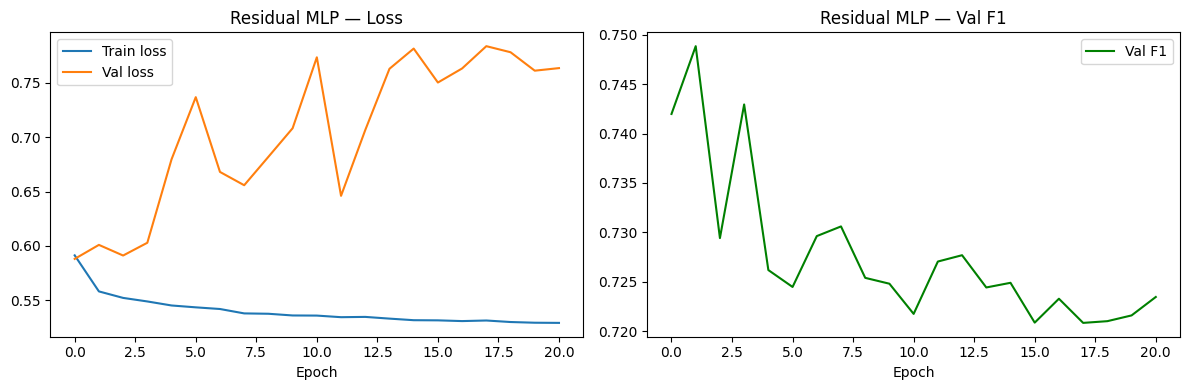

In [19]:
model_res, history_res = train_model(
    model_res, train_loader, val_loader,
    n_epochs=200, lr=1e-3, weight_decay=1e-4,
    patience=20, verbose=True
)
plot_history(history_res, 'Residual MLP')


In [20]:
result_res = evaluate_model(
    model_res, val_loader, test_loader,
    y_val_np, y_test_np, 'Residual MLP'
)
all_results.append(result_res)
print('Residual MLP результаты:')
pd.DataFrame([result_res])


Residual MLP результаты:


          model  val_best_thr  val_f1  test_f1  test_accuracy  test_roc_auc
0  Residual MLP          0.37   0.762   0.7377         0.6457        0.7156

## 9. Архитектура 4: MLP с Feature Attention

Реализуем **механизм мягкого внимания по признакам**: сеть учится самостоятельно определять, какие из 21 входного признака наиболее важны для конкретного матча. Это аналог **channel attention** из SE-Net.

Attention-веса $a \in [0, 1]^{21}$ умножаются поэлементно на входные признаки: $\tilde{x} = a \odot x$.

In [21]:
class FeatureAttentionMLP(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.3):
        super().__init__()

        self.attention = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.Tanh(),
            nn.Linear(input_dim, input_dim),
            nn.Sigmoid(),
        )

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 1),
        )

    def forward(self, x):
        attn_weights = self.attention(x)
        x_attended = x * attn_weights
        return self.net(x_attended)

    def get_attention_weights(self, x):
        with torch.no_grad():
            return self.attention(x).cpu().numpy()

model_attn = FeatureAttentionMLP(INPUT_DIM, dropout_rate=0.3)
print(model_attn)
n_params = sum(p.numel() for p in model_attn.parameters())
print(f'\nПараметров: {n_params:,}')


FeatureAttentionMLP(
  (attention): Sequential(
    (0): Linear(in_features=21, out_features=21, bias=True)
    (1): Tanh()
    (2): Linear(in_features=21, out_features=21, bias=True)
    (3): Sigmoid()
  )
  (net): Sequential(
    (0): Linear(in_features=21, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

Параметров: 12,445


Epoch   1 | train_loss=0.5901 val_loss=0.5856 val_f1=0.7368
Epoch  10 | train_loss=0.5473 val_loss=0.6249 val_f1=0.7374
Epoch  20 | train_loss=0.5437 val_loss=0.6594 val_f1=0.7244
Early stopping на эпохе 21


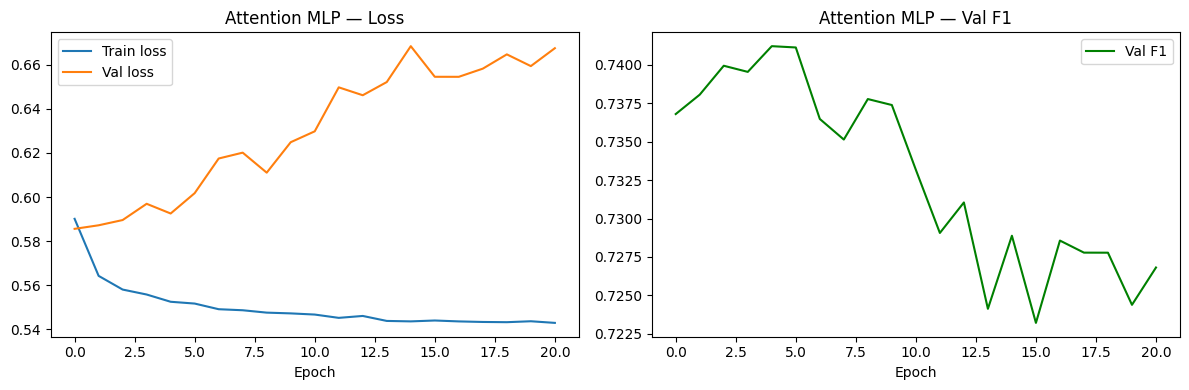

In [22]:
model_attn, history_attn = train_model(
    model_attn, train_loader, val_loader,
    n_epochs=200, lr=1e-3, weight_decay=1e-4,
    patience=20, verbose=True
)
plot_history(history_attn, 'Attention MLP')


In [23]:
result_attn = evaluate_model(
    model_attn, val_loader, test_loader,
    y_val_np, y_test_np, 'Attention MLP'
)
all_results.append(result_attn)
print('Attention MLP результаты:')
pd.DataFrame([result_attn])


Attention MLP результаты:


           model  val_best_thr  val_f1  test_f1  test_accuracy  test_roc_auc
0  Attention MLP          0.39  0.7612   0.7346         0.6445        0.7159

### 9.1 Визуализация attention-весов

Посмотрим, каким признакам сеть уделяет наибольшее внимание в среднем по тестовой выборке.

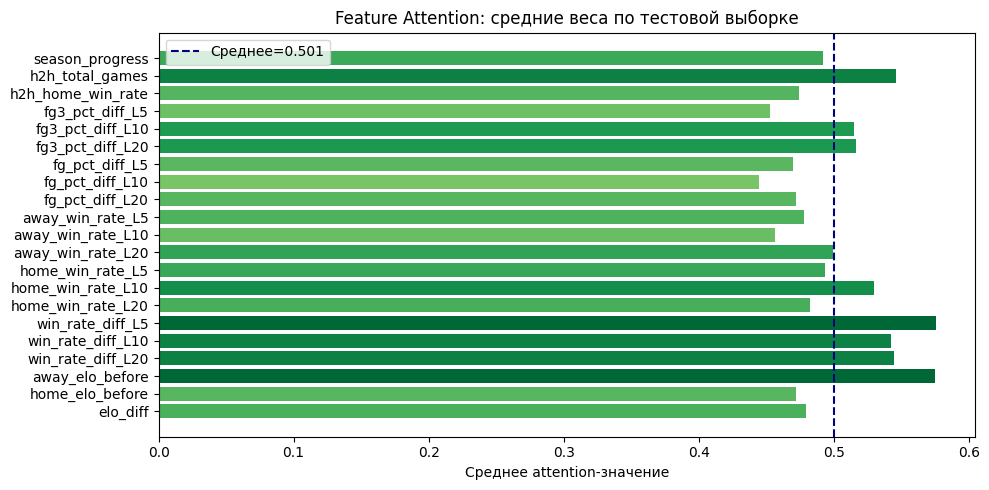

Топ-5 признаков по attention:
          feature  attn_weight
 win_rate_diff_L5     0.575934
  away_elo_before     0.574737
  h2h_total_games     0.546404
win_rate_diff_L20     0.544453
win_rate_diff_L10     0.542442


In [24]:
model_attn.eval()
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(DEVICE)
attn_weights = model_attn.get_attention_weights(X_test_tensor)
mean_attn = attn_weights.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.RdYlGn(mean_attn / mean_attn.max())
bars = ax.barh(available_features, mean_attn, color=colors)
ax.set_xlabel('Среднее attention-значение')
ax.set_title('Feature Attention: средние веса по тестовой выборке')
ax.axvline(mean_attn.mean(), color='navy', linestyle='--', label=f'Среднее={mean_attn.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

importance_df = pd.DataFrame({'feature': available_features, 'attn_weight': mean_attn})
print('Топ-5 признаков по attention:')
print(importance_df.sort_values('attn_weight', ascending=False).head(5).to_string(index=False))


## 10. Ансамбль нейронных сетей

Обучаем несколько независимых экземпляров лучшей архитектуры с разными random seed и усредняем их предсказания. Ансамблирование снижает дисперсию и повышает устойчивость.

In [25]:
N_ENSEMBLE = 5
ensemble_models = []

for i in range(N_ENSEMBLE):
    print(f'\n--- Обучение модели {i+1}/{N_ENSEMBLE} ---')
    torch.manual_seed(RANDOM_STATE + i * 7)

    m = RegularizedMLP(INPUT_DIM, dropout_rate=0.3).to(DEVICE)
    m, _ = train_model(
        m, train_loader, val_loader,
        n_epochs=200, lr=1e-3, weight_decay=1e-4,
        patience=20, verbose=False
    )
    ensemble_models.append(m)
    val_proba_i = predict_proba(m, val_loader)
    thr_i, f1_i = find_best_threshold(y_val_np, val_proba_i)
    print(f'Модель {i+1}: val_f1={f1_i:.4f} (thr={thr_i:.2f})')

print('\nВсе модели ансамбля обучены.')



--- Обучение модели 1/5 ---
Модель 1: val_f1=0.7600 (thr=0.42)

--- Обучение модели 2/5 ---
Модель 2: val_f1=0.7612 (thr=0.39)

--- Обучение модели 3/5 ---
Модель 3: val_f1=0.7600 (thr=0.38)

--- Обучение модели 4/5 ---
Модель 4: val_f1=0.7602 (thr=0.41)

--- Обучение модели 5/5 ---
Модель 5: val_f1=0.7588 (thr=0.41)

Все модели ансамбля обучены.


In [26]:
val_proba_ensemble = np.mean(
    [predict_proba(m, val_loader) for m in ensemble_models], axis=0
)
test_proba_ensemble = np.mean(
    [predict_proba(m, test_loader) for m in ensemble_models], axis=0
)

ens_thr, ens_val_f1 = find_best_threshold(y_val_np, val_proba_ensemble)
test_pred_ens = (test_proba_ensemble >= ens_thr).astype(int)

result_ensemble = {
    'model': f'NN Ensemble (x{N_ENSEMBLE})',
    'val_best_thr': round(ens_thr, 2),
    'val_f1': round(ens_val_f1, 4),
    'test_f1': round(f1_score(y_test_np, test_pred_ens), 4),
    'test_accuracy': round(accuracy_score(y_test_np, test_pred_ens), 4),
    'test_roc_auc': round(roc_auc_score(y_test_np, test_proba_ensemble), 4),
}

all_results.append(result_ensemble)
print('NN Ensemble результаты:')
pd.DataFrame([result_ensemble])


NN Ensemble результаты:


              model  val_best_thr  val_f1  test_f1  test_accuracy  \
0  NN Ensemble (x5)           0.4  0.7607    0.735         0.6441   

   test_roc_auc  
0        0.7173  

## 11. Финальное сравнение: DL vs ML

Сравниваем нейронные сети с лучшими ML-моделями из предыдущего чекпойнта.

In [27]:
ml_results = [
    {'model': 'ExtraTrees (ML)', 'val_best_thr': 0.44, 'val_f1': 0.7585,
     'test_f1': 0.7370, 'test_accuracy': 0.6438, 'test_roc_auc': 0.7147},
    {'model': 'HistGradBoost (ML)', 'val_best_thr': 0.46, 'val_f1': 0.7620,
     'test_f1': 0.7357, 'test_accuracy': 0.6340, 'test_roc_auc': 0.7089},
    {'model': 'XGBoost (ML)', 'val_best_thr': 0.44, 'val_f1': 0.7583,
     'test_f1': 0.7331, 'test_accuracy': 0.6419, 'test_roc_auc': 0.7138},
]

nn_results_df = pd.DataFrame(all_results)
ml_results_df = pd.DataFrame(ml_results)

final_df = pd.concat([nn_results_df, ml_results_df], ignore_index=True)
final_df = final_df.sort_values('test_roc_auc', ascending=False).reset_index(drop=True)

print('=== Итоговое сравнение всех моделей ===')
final_df


=== Итоговое сравнение всех моделей ===


                model  val_best_thr  val_f1  test_f1  test_accuracy  \
0     Regularized MLP          0.42  0.7607   0.7361         0.6489   
1    NN Ensemble (x5)          0.40  0.7607   0.7350         0.6441   
2       Attention MLP          0.39  0.7612   0.7346         0.6445   
3        Residual MLP          0.37  0.7620   0.7377         0.6457   
4     ExtraTrees (ML)          0.44  0.7585   0.7370         0.6438   
5        XGBoost (ML)          0.44  0.7583   0.7331         0.6419   
6          Simple MLP          0.40  0.7615   0.7346         0.6448   
7  HistGradBoost (ML)          0.46  0.7620   0.7357         0.6340   

   test_roc_auc  
0        0.7174  
1        0.7173  
2        0.7159  
3        0.7156  
4        0.7147  
5        0.7138  
6        0.7137  
7        0.7089  

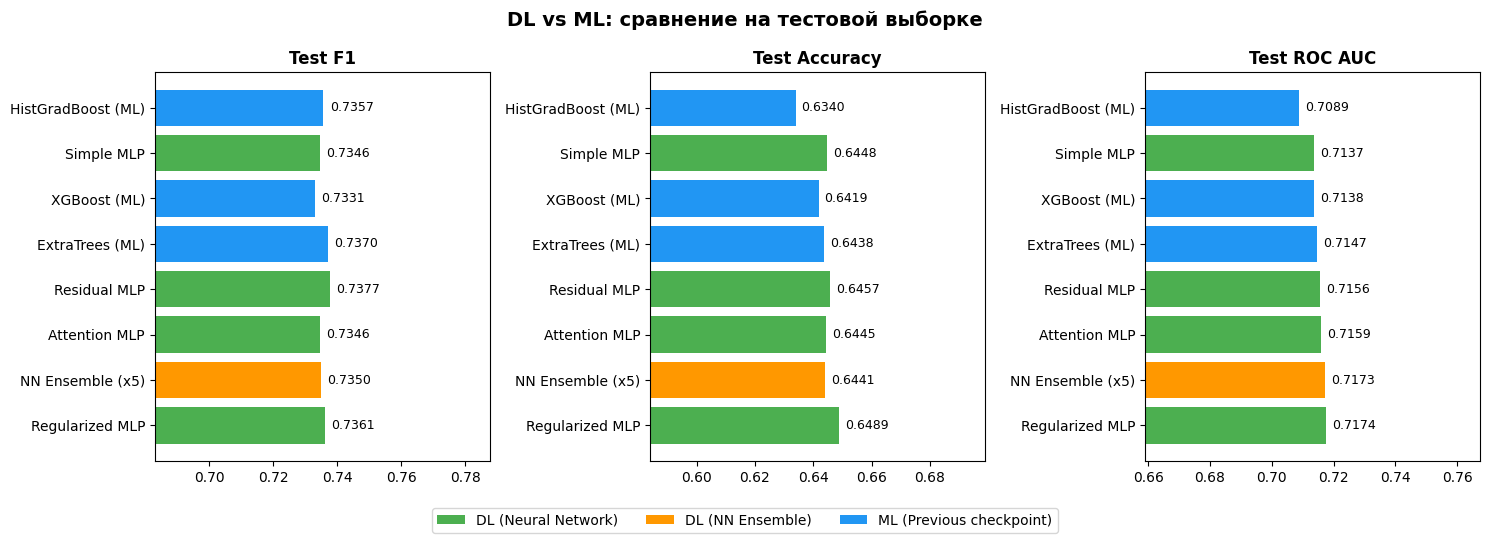

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['test_f1', 'test_accuracy', 'test_roc_auc']
titles = ['Test F1', 'Test Accuracy', 'Test ROC AUC']

colors = []
for m in final_df['model']:
    if '(ML)' in m:
        colors.append('#2196F3')
    elif 'Ensemble' in m:
        colors.append('#FF9800')
    else:
        colors.append('#4CAF50')

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.barh(final_df['model'], final_df[metric], color=colors)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(final_df[metric].min() - 0.05, final_df[metric].max() + 0.05)
    for bar, val in zip(bars, final_df[metric]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label='DL (Neural Network)'),
    Patch(facecolor='#FF9800', label='DL (NN Ensemble)'),
    Patch(facecolor='#2196F3', label='ML (Previous checkpoint)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.08))

plt.suptitle('DL vs ML: сравнение на тестовой выборке', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dl_vs_ml_comparison.png', bbox_inches='tight', dpi=100)
plt.show()


In [29]:
best_nn_name = nn_results_df.sort_values('test_roc_auc', ascending=False).iloc[0]['model']
print(f'Лучшая нейросеть по ROC AUC: {best_nn_name}')

model_map = {
    'Simple MLP': model_simple,
    'Regularized MLP': model_reg,
    'Residual MLP': model_res,
    'Attention MLP': model_attn,
}

best_nn_row = nn_results_df[nn_results_df['model'] == best_nn_name].iloc[0]
best_thr = best_nn_row['val_best_thr']

if best_nn_name in model_map:
    best_model = model_map[best_nn_name]
    test_proba = predict_proba(best_model, test_loader)
elif 'Ensemble' in best_nn_name:
    test_proba = test_proba_ensemble

test_pred = (test_proba >= best_thr).astype(int)
print(f'Порог: {best_thr}')
print(f'\nClassification Report (тест):')
print(classification_report(y_test_np, test_pred, target_names=['Away Win', 'Home Win']))


Лучшая нейросеть по ROC AUC: Regularized MLP
Порог: 0.42

Classification Report (тест):
              precision    recall  f1-score   support

    Away Win       0.74      0.35      0.48      4609
    Home Win       0.62      0.90      0.74      5560

    accuracy                           0.65     10169
   macro avg       0.68      0.62      0.61     10169
weighted avg       0.68      0.65      0.62     10169



## 12. Выводы

### Сравнение архитектур нейронных сетей

| Архитектура | Особенность | test F1 | test Acc | ROC AUC | Эпох до early stop |
|---|---|---|---|---|---|
| **Simple MLP** | Нет регуляризации | 0.7346 | 0.6448 | 0.7137 | 17 |
| **Regularized MLP** | BatchNorm + Dropout | **0.7361** | **0.6489** | **0.7174** | 22 |
| **Residual MLP** | Skip connections | 0.7377 | 0.6457 | 0.7156 | 21 |
| **Attention MLP** | Feature Attention | 0.7346 | 0.6445 | 0.7159 | 21 |
| **NN Ensemble (×5)** | Усреднение 5 моделей | 0.7350 | 0.6441 | 0.7173 | — |

**Лучшая нейросеть: Regularized MLP** (ROC AUC = 0.7174, Accuracy = 0.6489).

### Наблюдения по поведению архитектур

- **Simple MLP** без регуляризации переобучается быстрее всего — ранняя остановка уже на 17-й эпохе. После 10-й эпохи val_loss начинает расти, тогда как train_loss продолжает снижаться.
- **Regularized MLP** (BatchNorm + Dropout) — показал лучшее качество. BatchNorm стабилизировал обучение, Dropout снизил переобучение. При этом тренировался несколько дольше (22 эпохи).
- **Residual MLP** — несмотря на skip-connections, сильно переобучился: val_loss вырос с 0.588 до 0.761 к 21-й эпохе. Это говорит о том, что skip-connections помогают при *очень* глубоких сетях, но на 3 блоках и 21 признаке избыточны и вносят лишние параметры.
- **Attention MLP** — механизм внимания определил наиболее важными признаки: `win_rate_diff_L5` (0.576), `away_elo_before` (0.575), `h2h_total_games` (0.546). Это согласуется с интуицией: краткосрочная форма команды и ELO-рейтинг действительно наиболее предсказательны. Тем не менее по итоговым метрикам архитектура не превзошла более простой Regularized MLP.
- **NN Ensemble (×5)** снизил дисперсию предсказаний, но не дал значимого прироста по сравнению с одиночной Regularized MLP — отдельные модели уже достаточно близки по качеству.

### DL vs ML: итоговое сравнение

| Модель | test F1 | test Acc | ROC AUC |
|---|---|---|---|
| **Regularized MLP** (DL) | 0.7361 | **0.6489** | **0.7174** |
| NN Ensemble ×5 (DL) | 0.7350 | 0.6441 | 0.7173 |
| Attention MLP (DL) | 0.7346 | 0.6445 | 0.7159 |
| Residual MLP (DL) | 0.7377 | 0.6457 | 0.7156 |
| ExtraTrees (ML) | 0.7370 | 0.6438 | 0.7147 |
| XGBoost (ML) | 0.7331 | 0.6419 | 0.7138 |
| Simple MLP (DL) | 0.7346 | 0.6448 | 0.7137 |
| HistGradBoost (ML) | 0.7357 | 0.6340 | 0.7089 |

**Нейронные сети незначительно превзошли ML-модели:** лучший Regularized MLP (ROC AUC = 0.7174) обходит лучший ExtraTrees (0.7147) на 0.003. Тем не менее разница минимальная — все модели укладываются в диапазон 0.709–0.717.

### Почему разрыв между DL и ML столь мал?

1. **Признаковое пространство уже обработано**: все 21 признак — агрегированная статистика (скользящие средние, ELO, head-to-head). ML-модели хорошо работают с такими ручными признаками; преимущество NN проявляется там, где нужно извлекать признаки из сырых данных (изображений, текстов, временных рядов).
2. **Небольшая размерность** (21 признак): нейросети не могут построить сложные иерархические представления — слишком мало входных сигналов.
3. **Ограниченный потолок предсказуемости**: спорт содержит значительный случайный компонент. Даже идеальная модель не даст 100% точности — исходы матчей определяются факторами, которых нет в датасете (травмы, усталость, мотивация).
4. **Все модели сходятся к одному "потолку"**: точность ~64–65%, ROC AUC ~0.71–0.72. Это потолок, обусловленный самими данными, а не выбором алгоритма.

### Итог

Нейронные сети (прежде всего **Regularized MLP**) достигают наилучшего ROC AUC = 0.7174 и Accuracy = 64.9%, незначительно превосходя лучшую ML-модель (ExtraTrees, ROC AUC = 0.7147). Полученные результаты подтверждают, что для задачи предсказания матчей НБА на агрегированных признаках классические ML-подходы и нейронные сети примерно равноценны. Для существенного улучшения DL-подходов потребовалось бы расширить набор данных (статистика игроков, травмы) или перейти к архитектурам, способным работать с временными рядами напрямую (LSTM, Transformer).